<p style="font-family:Bookman Old Style;font-size:27px; text-align:center">Discrete Fourier Transform(DFT)</p>

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">The basic idea behind the Fourier transform method is that an image can be thought of as a 2D function, f, that can be expressed as a weighted sum of sines and cosines (Fourier basic functions) along two dimensions.</p></div>

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">We can transition from a set of grayscale pixel values in the image (spatial/time domain) to
 a set of Fourier coefficients (frequency domain) using the DFT, and it is discrete since the
 spatial and the transform variables to be used can only take a set of discrete consecutive
 integer values (typically the locations of a 2D array representing the image).
 In a similar way, the frequency domain 2D array of Fourier coefficients can be converted
 back into the spatial domain using the Inverse Discrete Fourier Transform (IDFT), which
 is also known as reconstruction of the image using the Fourier coefficients.</p></div>

<p style="font-family:Bookman Old Style;font-size:27px">The Fast Fourier Transform algorithm to compute the DFT</p>

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">The Fast Fourier Transform (FFT) is a divide and conquer algorithm to recursively compute the DFT much quicker (with O(N.log2N) time complexity) than the much slower O(N2) naive computation for an n x n image. In Python, both the numpy and scipy libraries provide functions to compute 2D DFT/IDFT using the FFT algorithm. Let's see a few examples.</p></div>

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">We'll use the scipy.fftpack module's fft2()/ifft2() function to compute the DFT/IDFT with the FFT algorithm using a grayscale image,clock1.jpg:</p></div>

<p style="font-family:Bookman Old Style;font-size:27px">Import libraries</p>

In [20]:
from PIL import Image
import numpy as np
import scipy.fftpack as fp
import matplotlib.pyplot as plt

<p style="font-family:Bookman Old Style;font-size:27px">Calculates the Signal-to-Noise Ratio (SNR) for an image</p>

In [21]:
def calc_snr(image):
    signal = np.mean(image)  # mean of the signal
    noise = np.std(image)
    if noise != 0:
        return signal / noise
    else:
        return 0

<p style="font-family:Bookman Old Style;font-size:27px">Loading the image</p>

In [22]:
img = Image.open('../images-videos/clock1.jpg')

<p style="font-family:Bookman Old Style;font-size:27px">Converting image to Grayscale</p>

In [23]:
img = img.convert('L')
im = np.array(img)

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">The grayscale image is then converted to a NumPy array for further numerical operations.</p></div>

<p style="font-family:Bookman Old Style;font-size:27px">Calculating the SNR of the original image</p>

In [24]:
snr_img = calc_snr(im)

<p style="font-family:Bookman Old Style;font-size:27px">Computing the FFT of the image</p>

In [25]:
freq_img = fp.fft2(im)

<p style="font-family:Bookman Old Style;font-size:27px">Reconstructing the image using IFFT</p>

In [26]:
new_img = fp.ifft2(freq_img).real

<p style="font-family:Bookman Old Style;font-size:27px">Calculating the SNR of the reconstructed image</p>

In [27]:
snr_newImg = calc_snr(new_img)

<p style="font-family:Bookman Old Style;font-size:27px">Visualizing the image</p>

SNR for original image is:  1.9300649054511847
SNR for reconstructed image is:  1.930064905451185


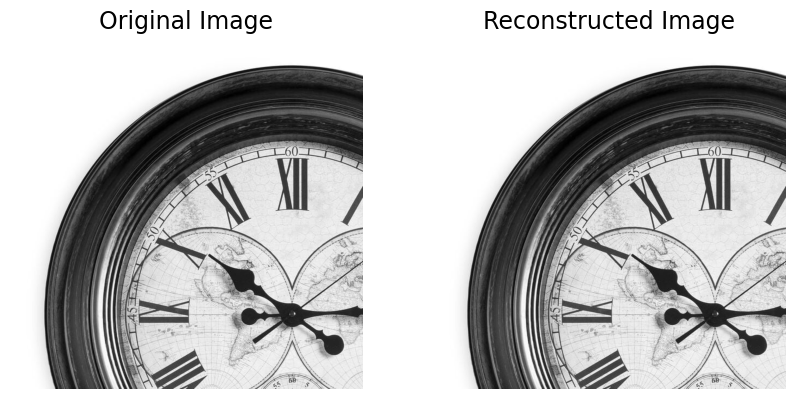

In [28]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title('Original Image', size=17)
plt.axis('off')
print('SNR for original image is: ', snr_img)

plt.subplot(122)
plt.imshow(new_img, cmap='gray')
plt.title('Reconstructed Image', size=17)
plt.axis('off')
print('SNR for reconstructed image is: ', snr_newImg)
plt.show()


<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">As can be seen from the SNR values from the inline output and from the visual difference in the input and the reconstructed image, the reconstructed image loses some information. The difference is negligible if we use all of the coefficients obtained for reconstruction</p></div>